In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/customer-personality-analysis/marketing_campaign.csv


# Customer Personality Analysis 
* Customer Personality Analysis is a dataset that Analyzes ideal customers of a company. 
* Our data contains information about work, products, promotion, and place.

# People

* ID: Customer's unique identifier
* Year_Birth: Customer's birth year
* Education: Customer's education level
* Marital_Status: Customer's marital status
* Income: Customer's yearly household income
* Kidhome: Number of children in customer's household
* Teenhome: Number of teenagers in customer's household
* Dt_Customer: Date of customer's enrollment with the company
* Recency: Number of days since customer's last purchase
* Complain: 1 if the customer complained in the last 2 years, 0 otherwise

# Products

* MntWines: Amount spent on wine in last 2 years
* MntFruits: Amount spent on fruits in last 2 years
* MntMeatProducts: Amount spent on meat in last 2 years
* MntFishProducts: Amount spent on fish in last 2 years
* MntSweetProducts: Amount spent on sweets in last 2 years
* MntGoldProds: Amount spent on gold in last 2 years

# Promotion

* NumDealsPurchases: Number of purchases made with a discount
* AcceptedCmp1: 1 if customer accepted the offer in the 1st campaign, 0 otherwise
* AcceptedCmp2: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
* AcceptedCmp3: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
* AcceptedCmp4: 1 if customer accepted the offer in the 4th campaign, 0 otherwise
* AcceptedCmp5: 1 if customer accepted the offer in the 5th campaign, 0 otherwise
* Response: 1 if customer accepted the offer in the last campaign, 0 otherwise

# Place

* NumWebPurchases: Number of purchases made through the company’s website
* NumCatalogPurchases: Number of purchases made using a catalogue
* NumStorePurchases: Number of purchases made directly in stores
* NumWebVisitsMonth: Number of visits to company’s website in the last month

# Libraries

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("/kaggle/input/customer-personality-analysis/marketing_campaign.csv",sep="\t")

In [4]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [5]:
df.shape

(2240, 29)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [7]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [10]:
df.corr(numeric_only=True)

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,1.000000,0.000028,0.013095,0.002406,-0.002580,-0.046524,-0.022878,0.004600,-0.004437,-0.024475,...,-0.007446,-0.036040,-0.025387,-0.007517,-0.021614,-0.015061,0.033883,NaN,NaN,-0.021968
Year_Birth,0.000028,1.000000,-0.161791,0.230176,-0.352111,-0.019871,-0.157773,-0.017917,-0.030872,-0.041625,...,0.121139,0.061774,-0.060510,0.007123,-0.005930,-0.006539,-0.030128,NaN,NaN,0.021325
Income,0.013095,-0.161791,1.000000,-0.428669,0.019133,-0.003970,0.578650,0.430842,0.584633,0.438871,...,-0.553088,-0.016174,0.184400,0.335943,0.276820,0.087545,-0.027225,NaN,NaN,0.133047
Kidhome,0.002406,0.230176,-0.428669,1.000000,-0.036133,0.008827,-0.496297,-0.372581,-0.437129,-0.387644,...,0.447846,0.014674,-0.161600,-0.205634,-0.172339,-0.081716,0.040207,NaN,NaN,-0.080008
Teenhome,-0.002580,-0.352111,0.019133,-0.036133,1.000000,0.016198,0.004846,-0.176764,-0.261160,-0.204187,...,0.134884,-0.042677,0.038886,-0.191050,-0.140090,-0.015605,0.003138,NaN,NaN,-0.154446
Recency,-0.046524,-0.019871,-0.003970,0.008827,0.016198,1.000000,0.016064,-0.004306,0.023056,0.001079,...,-0.021445,-0.032991,0.018826,0.000129,-0.019283,-0.001781,0.013231,NaN,NaN,-0.198437
MntWines,-0.022878,-0.157773,0.578650,-0.496297,0.004846,0.016064,1.000000,0.389637,0.562667,0.399753,...,-0.320653,0.062202,0.373286,0.472613,0.354133,0.205907,-0.039007,NaN,NaN,0.247254
MntFruits,0.004600,-0.017917,0.430842,-0.372581,-0.176764,-0.004306,0.389637,1.000000,0.543105,0.594804,...,-0.418383,0.014727,0.010152,0.215833,0.194748,-0.009773,-0.005166,NaN,NaN,0.125289
MntMeatProducts,-0.004437,-0.030872,0.584633,-0.437129,-0.261160,0.023056,0.562667,0.543105,1.000000,0.568402,...,-0.539470,0.018272,0.102912,0.373769,0.309761,0.043033,-0.023483,NaN,NaN,0.236335
MntFishProducts,-0.024475,-0.041625,0.438871,-0.387644,-0.204187,0.001079,0.399753,0.594804,0.568402,1.000000,...,-0.446003,0.000357,0.016843,0.199578,0.260762,0.002577,-0.020953,NaN,NaN,0.111331


<Axes: >

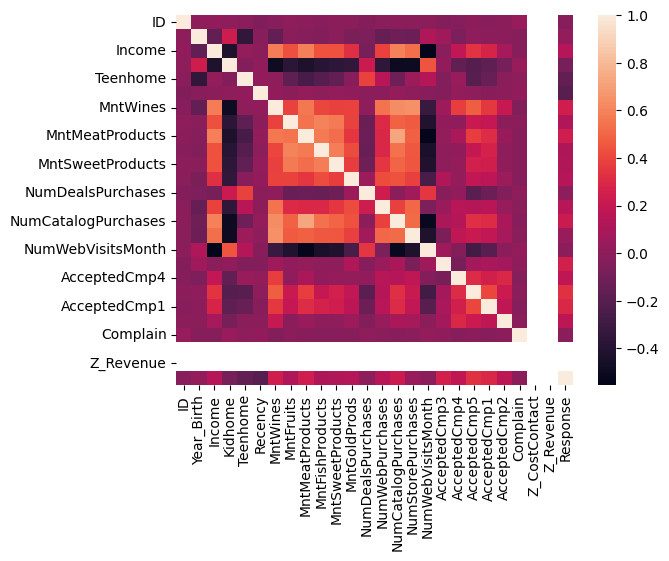

In [11]:
sns.heatmap(df.corr(numeric_only=True))

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

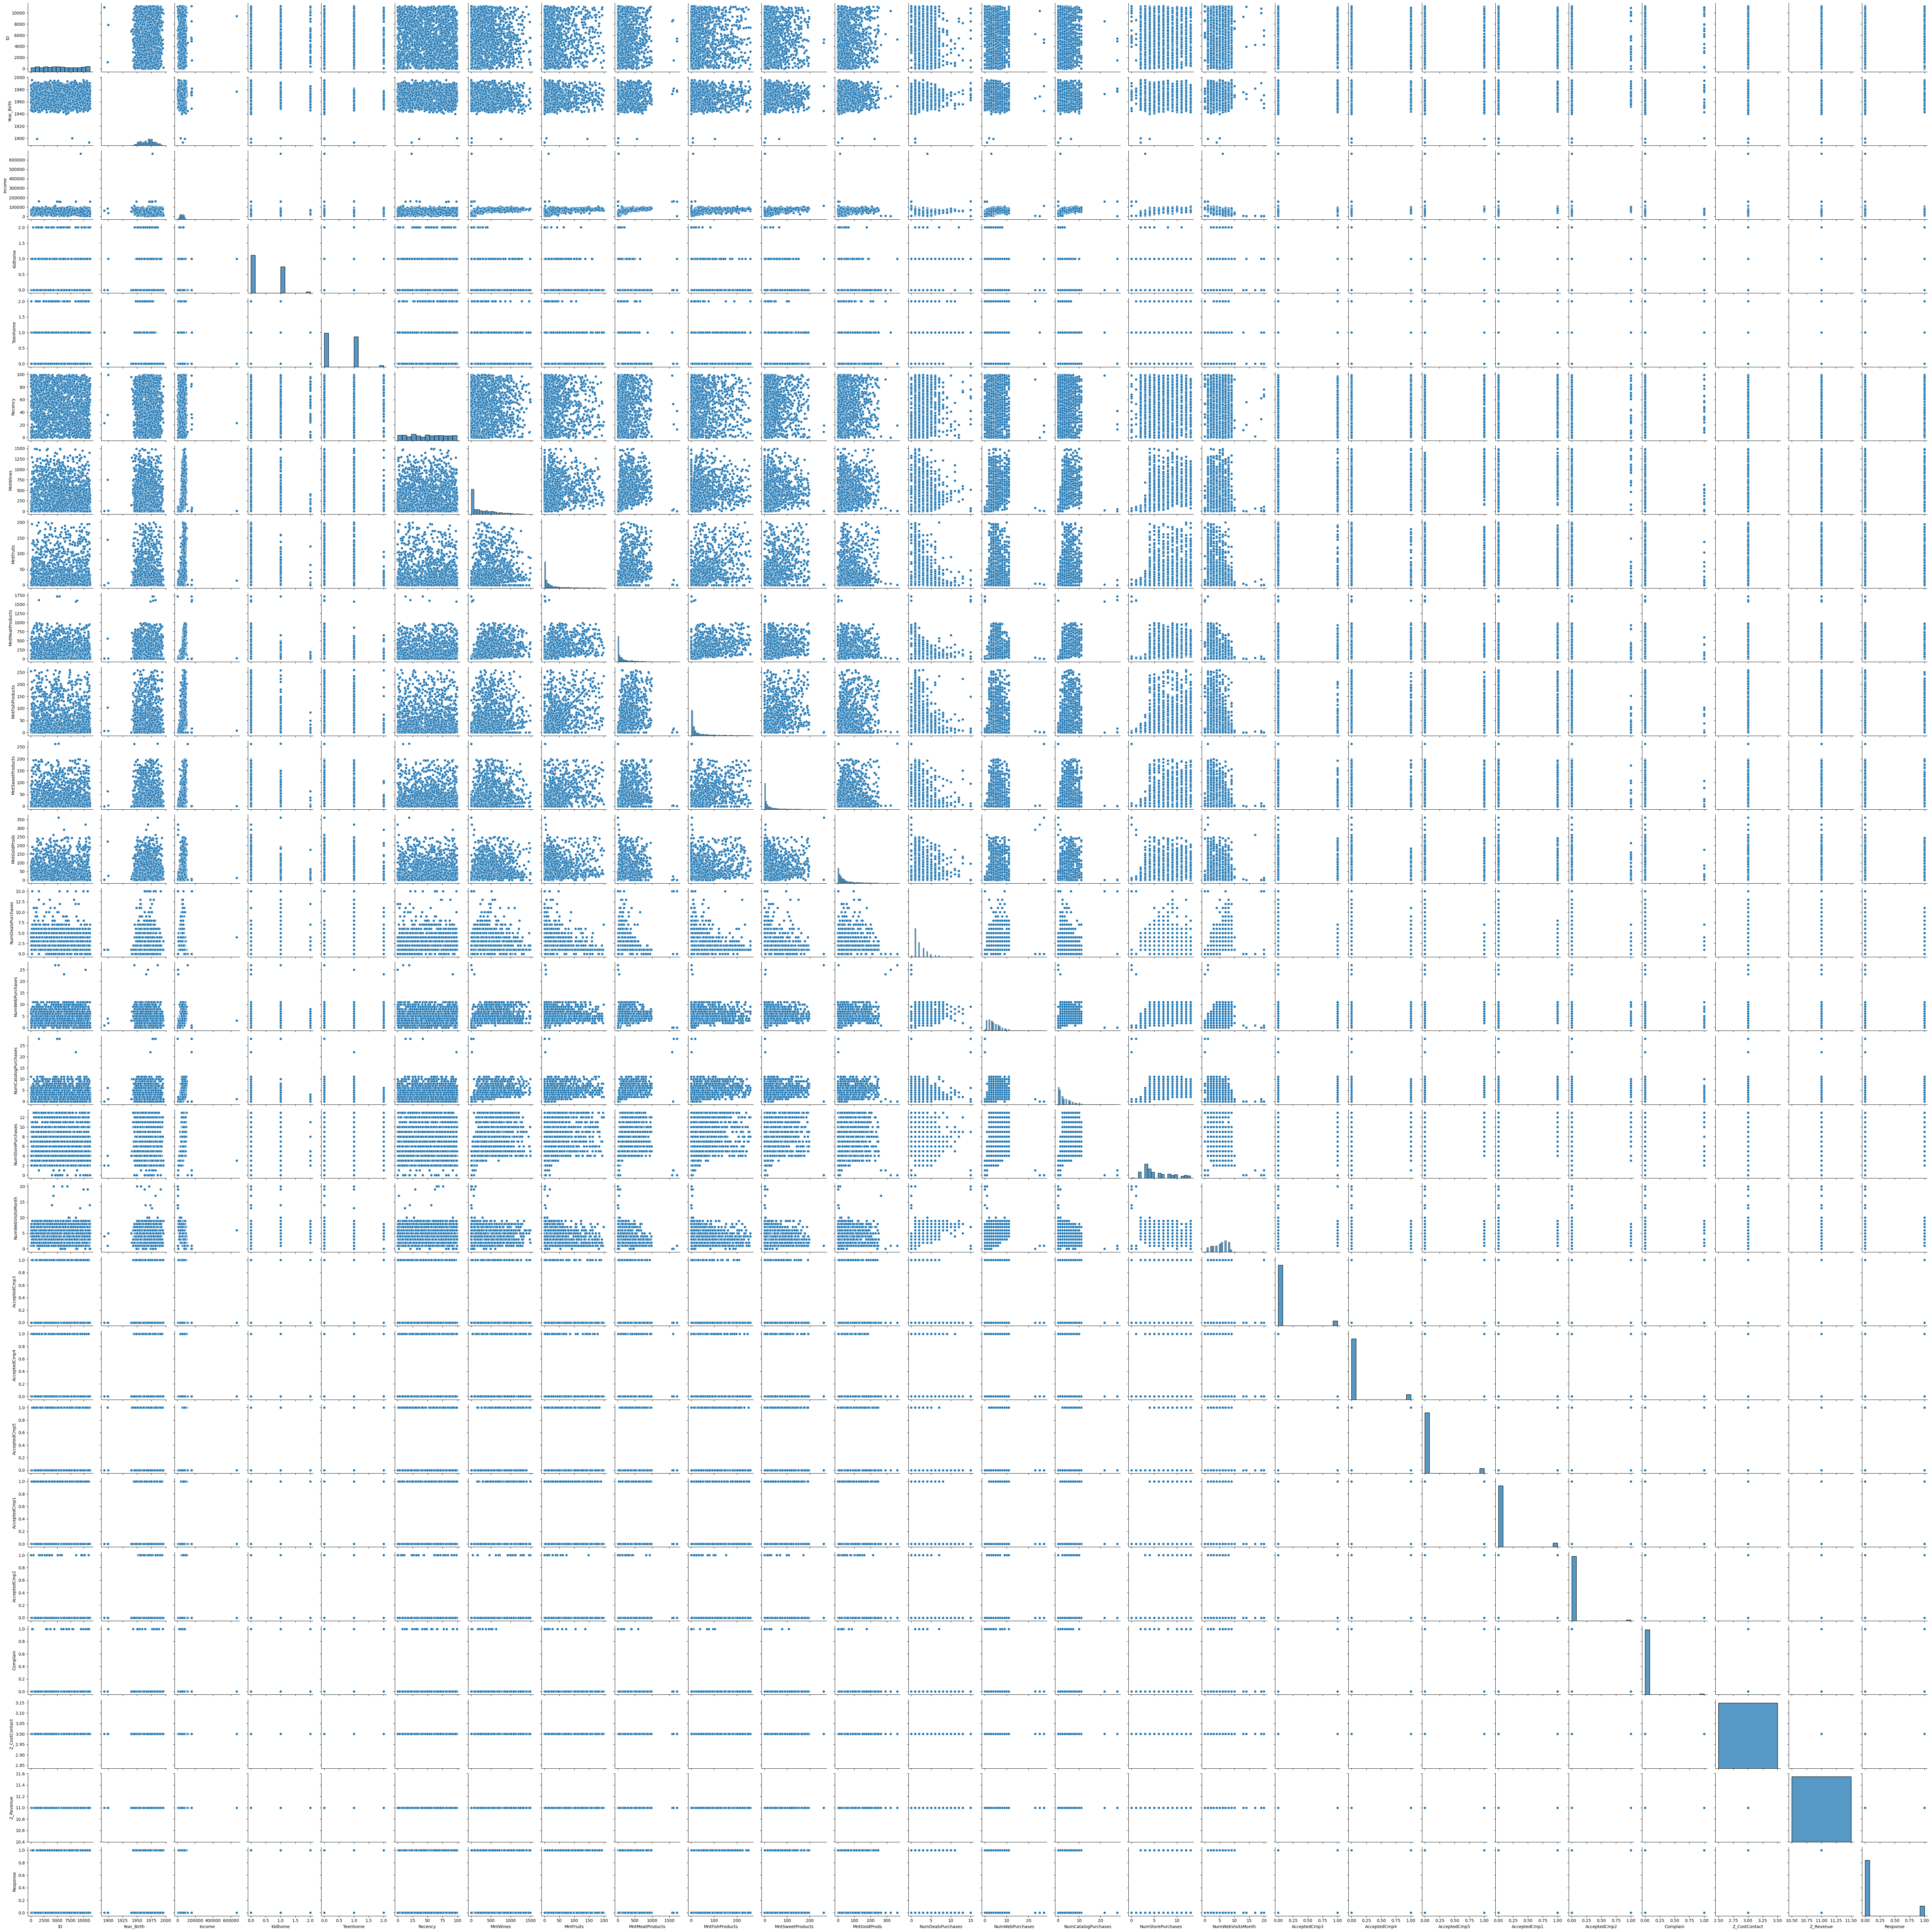

In [12]:
sns.pairplot(data=df)
plt.show()

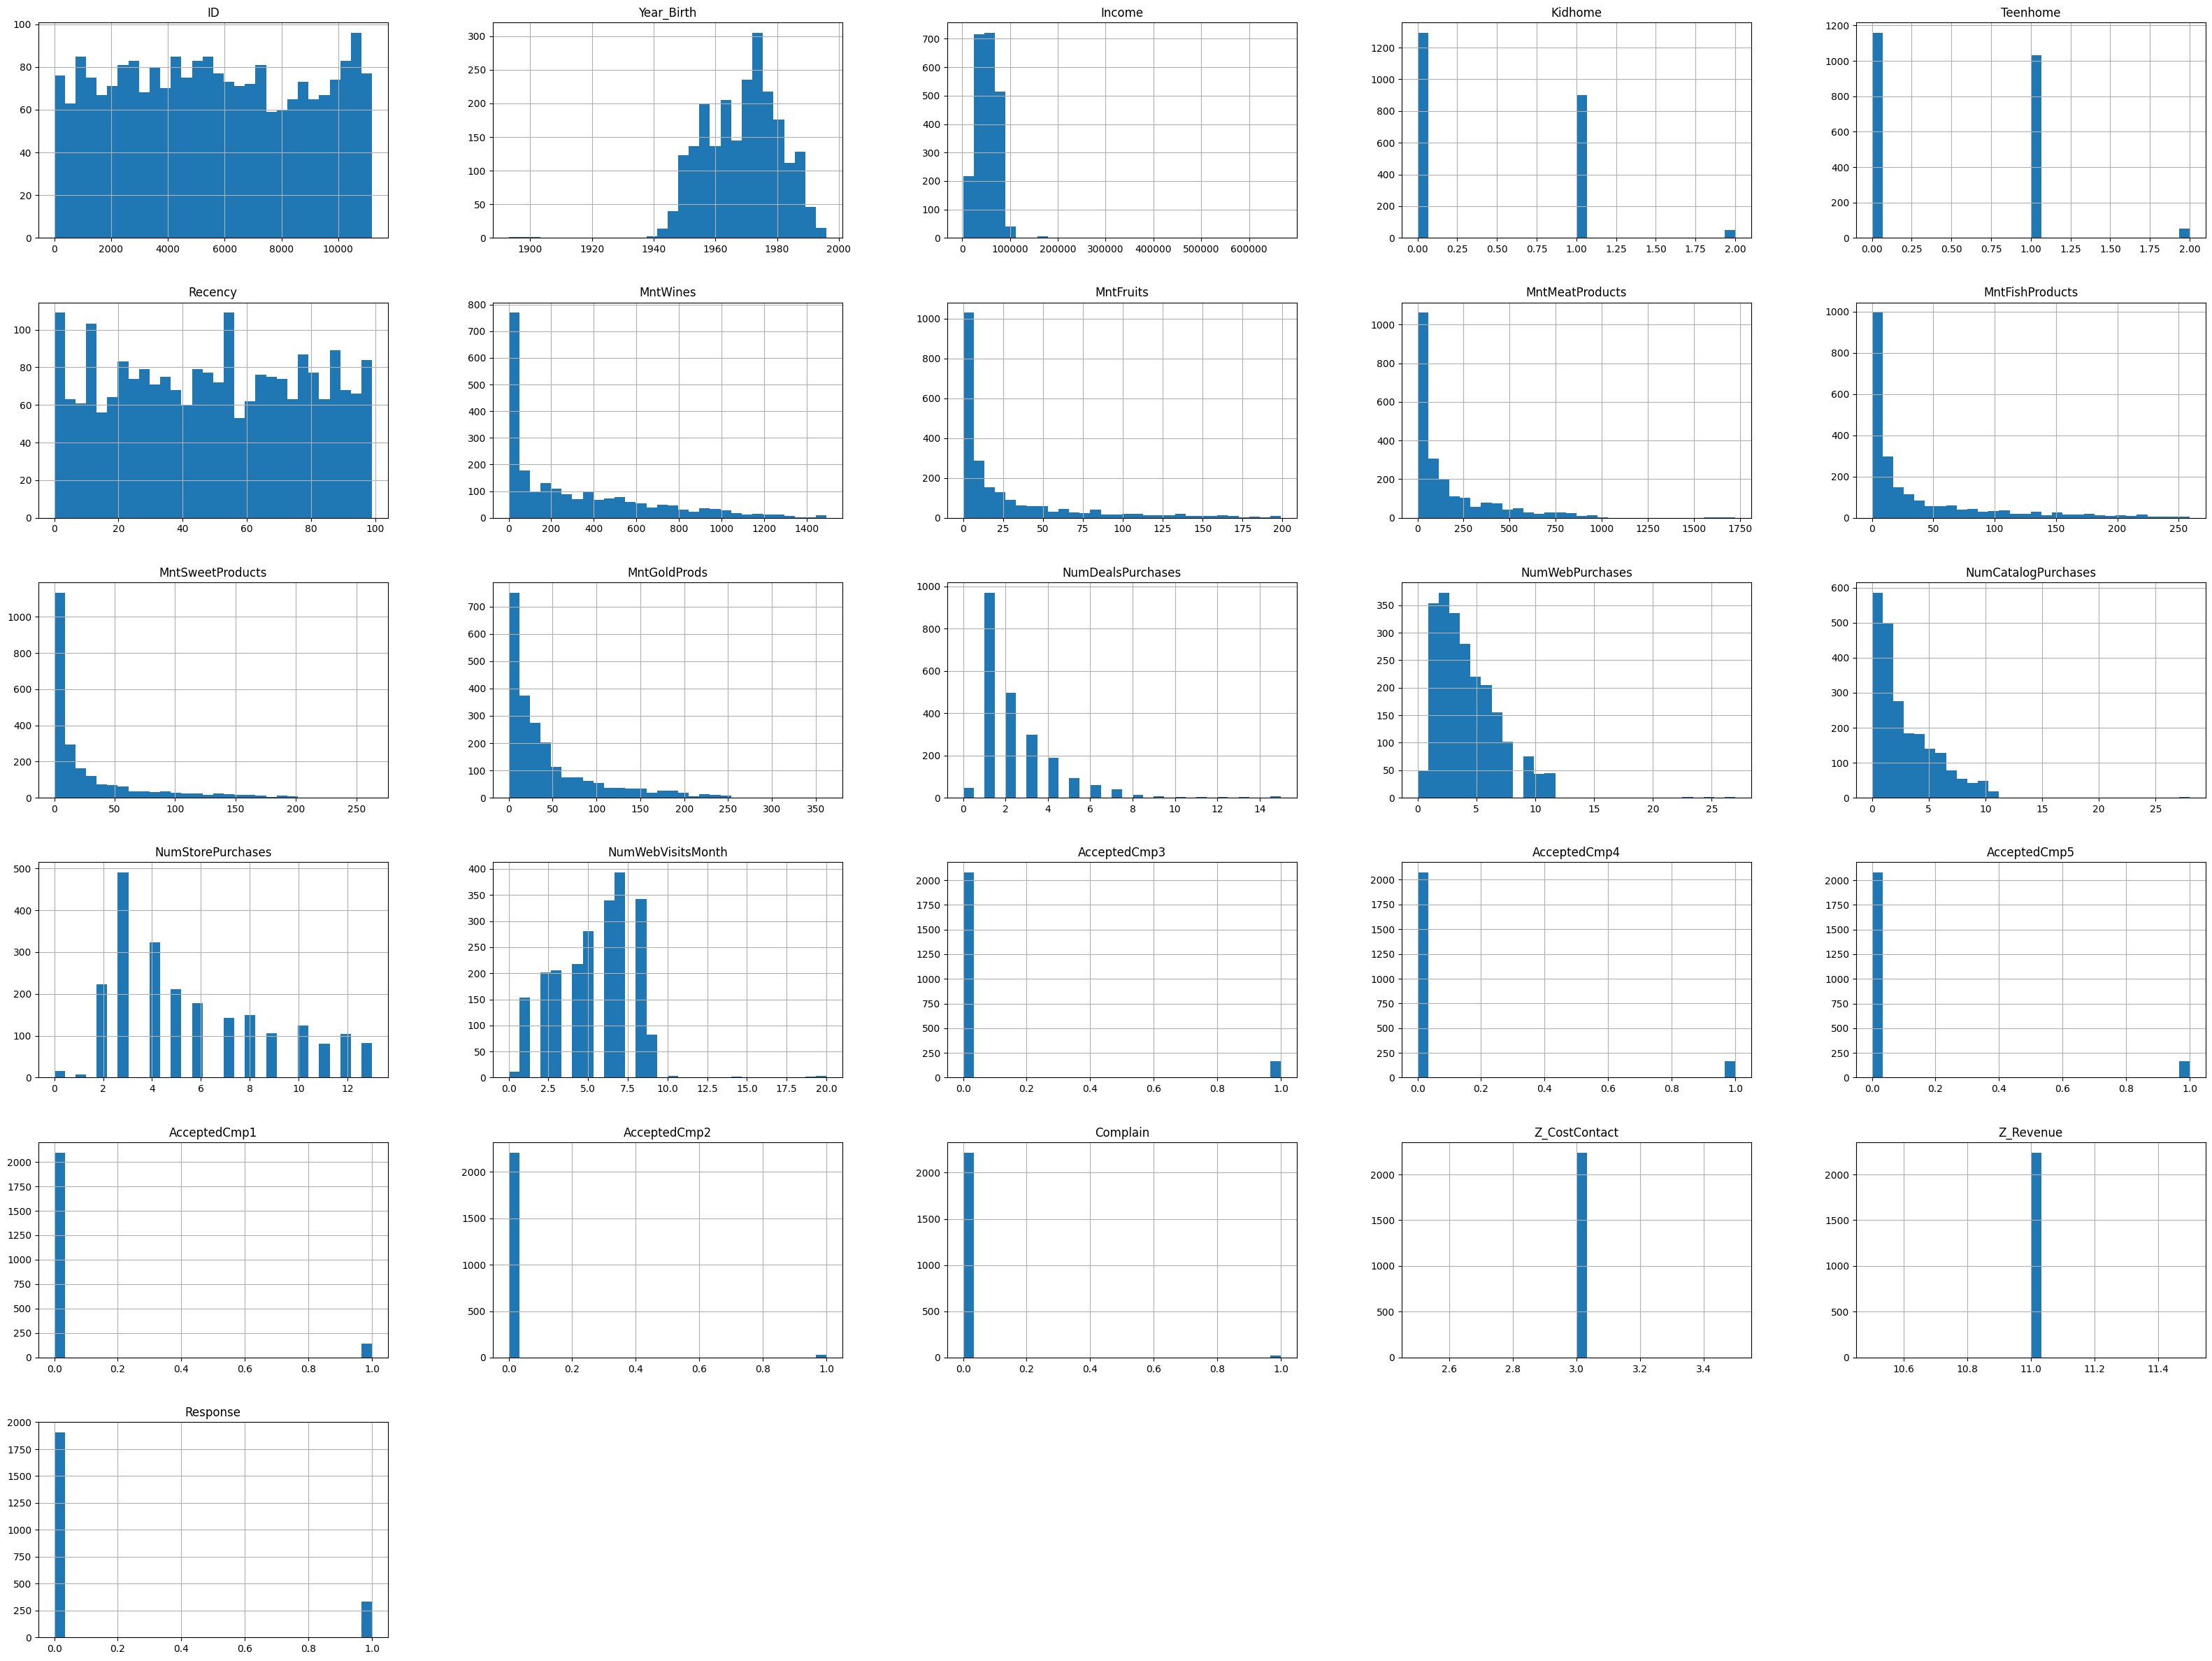

In [13]:
df.hist(bins=30, figsize=(40, 30))
plt.show()

> Customer

In [14]:
customer=['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'Complain']
customer_data=df[customer]

In [15]:
customer_data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,Complain
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,0
...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,0


In [16]:
customer_data["Age"]= 2024 - customer_data["Year_Birth"]
customer_data

/tmp/ipykernel_17/2555078400.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer_data["Age"]= 2024 - customer_data["Year_Birth"]


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,Complain,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,0,67
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,0,70
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,0,59
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,0,40
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,0,43
...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,0,57
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,0,78
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,0,43
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,0,68


In [17]:
customer_data.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,Complain,Age
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,0.009375,55.194196
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,0.096391,11.984069
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,28.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,0.000000,47.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,0.000000,54.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,0.000000,65.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1.000000,131.000000


In [18]:
customer_data.corr(numeric_only=True)

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,Complain,Age
ID,1.000000,0.000028,0.013095,0.002406,-0.002580,-0.046524,0.033883,-0.000028
Year_Birth,0.000028,1.000000,-0.161791,0.230176,-0.352111,-0.019871,-0.030128,-1.000000
Income,0.013095,-0.161791,1.000000,-0.428669,0.019133,-0.003970,-0.027225,0.161791
Kidhome,0.002406,0.230176,-0.428669,1.000000,-0.036133,0.008827,0.040207,-0.230176
Teenhome,-0.002580,-0.352111,0.019133,-0.036133,1.000000,0.016198,0.003138,0.352111
Recency,-0.046524,-0.019871,-0.003970,0.008827,0.016198,1.000000,0.013231,0.019871
Complain,0.033883,-0.030128,-0.027225,0.040207,0.003138,0.013231,1.000000,0.030128
Age,-0.000028,-1.000000,0.161791,-0.230176,0.352111,0.019871,0.030128,1.000000


<Axes: >

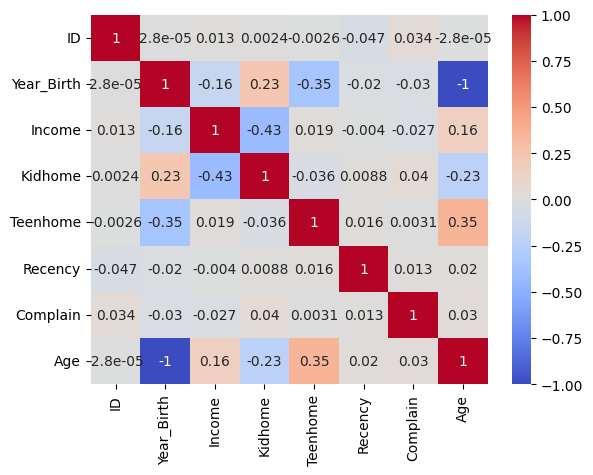

In [19]:
sns.heatmap(customer_data.corr(numeric_only=True), annot=True, cmap='coolwarm')

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

<Axes: xlabel='Income', ylabel='Density'>

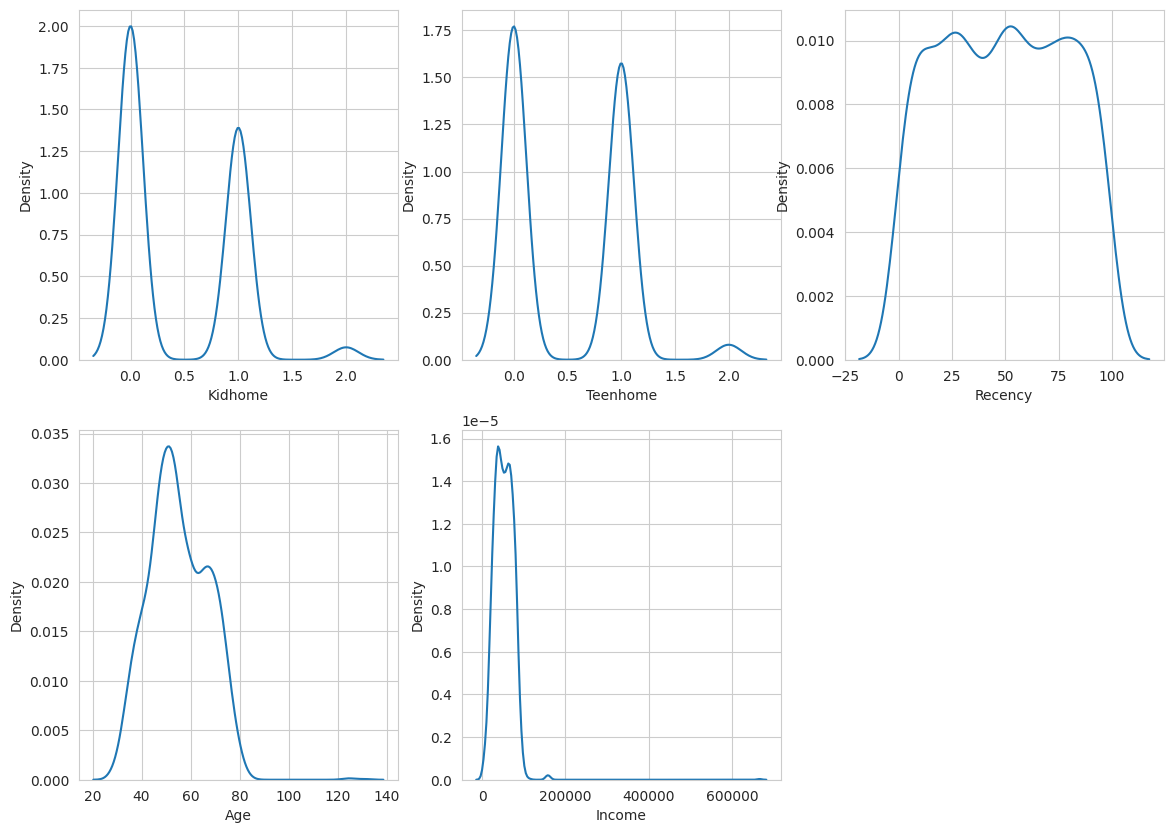

In [20]:
plt.figure(figsize=(14,10))
sns.set_style(style='whitegrid')
plt.subplot(2,3,1)
sns.kdeplot(x='Kidhome',data=customer_data)
plt.subplot(2,3,2)
sns.kdeplot(x='Teenhome',data=customer_data)
plt.subplot(2,3,3)
sns.kdeplot(x='Recency',data=customer_data)
plt.subplot(2,3,4)
sns.kdeplot(x='Age',data=customer_data)
plt.subplot(2,3,5)
sns.kdeplot(x='Income',data=customer_data)

<Axes: xlabel='Age', ylabel='Income'>

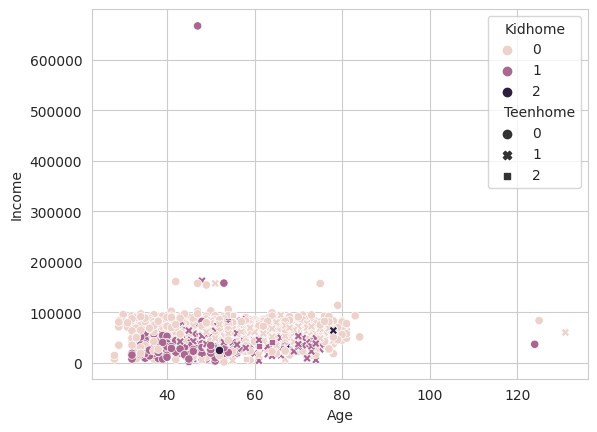

In [21]:
sns.scatterplot(data=customer_data, x='Age', y='Income',hue='Kidhome',style='Teenhome')

In [22]:
customer_data.Education.value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

<Axes: xlabel='Education'>

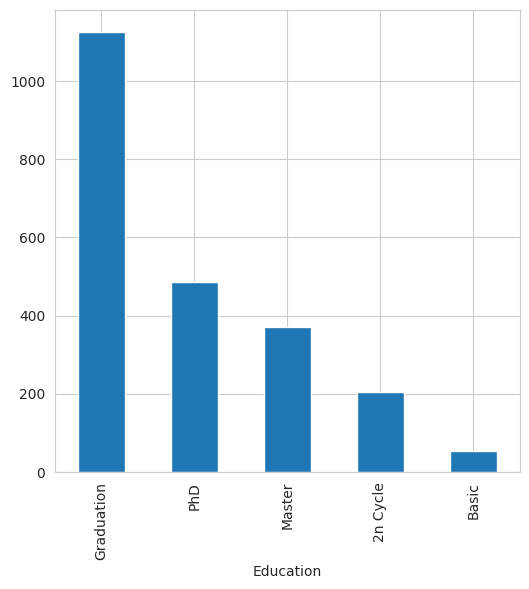

In [23]:
customer_data.Education.value_counts().plot(kind='bar' , figsize=(6,6))

In [24]:
customer_data.Marital_Status.value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

<Axes: xlabel='Marital_Status'>

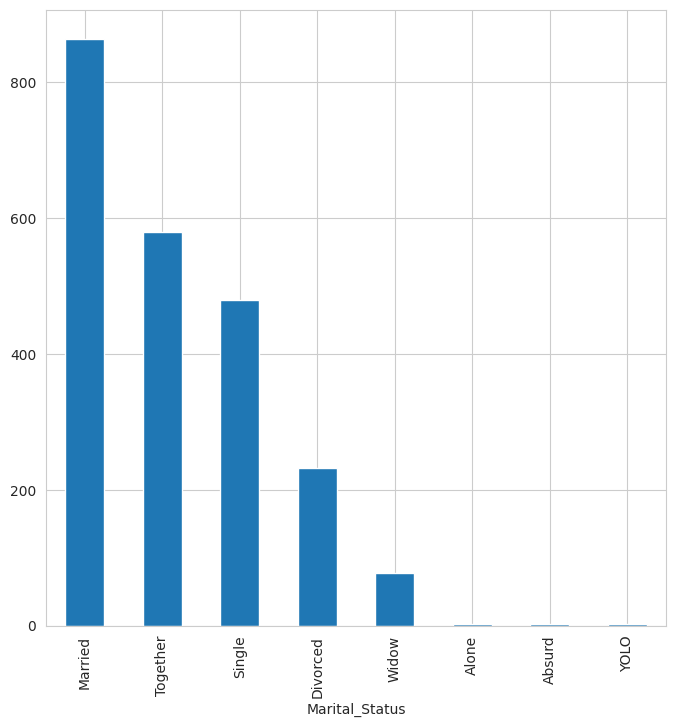

In [25]:
customer_data.Marital_Status.value_counts().plot(kind='bar' , figsize=(8,8))

In [26]:
customer_data.Income.value_counts()

Income
7500.0     12
35860.0     4
37760.0     3
83844.0     3
63841.0     3
           ..
40760.0     1
41452.0     1
6835.0      1
33622.0     1
52869.0     1
Name: count, Length: 1974, dtype: int64

In [27]:
customer_data.Income.min()

1730.0

In [28]:
customer_data.Income.max()

666666.0

In [29]:
customer_data.Income.mean()

52247.25135379061

In [30]:
customer_data.Kidhome.value_counts()

Kidhome
0    1293
1     899
2      48
Name: count, dtype: int64

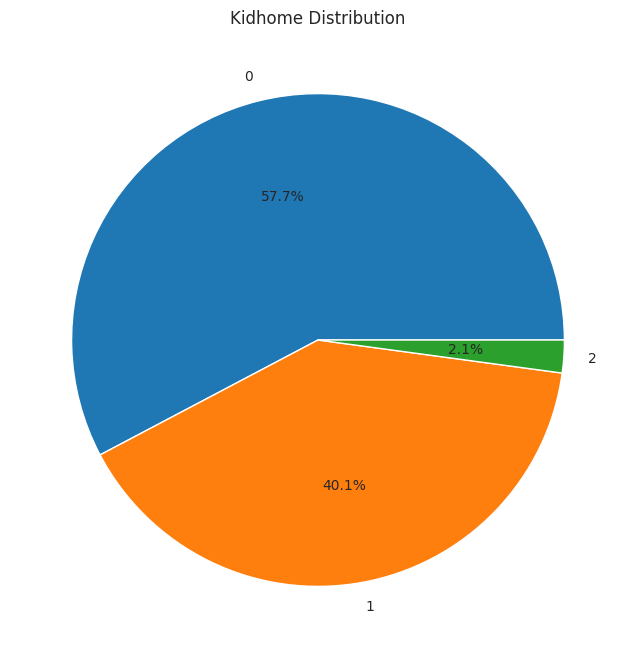

In [31]:
plt.figure(figsize=(8, 8))
plt.pie(customer_data['Kidhome'].value_counts(), labels=customer_data['Kidhome'].value_counts().index, autopct='%1.1f%%')
plt.title('Kidhome Distribution')
plt.show()

In [32]:
customer_data.Teenhome.value_counts()

Teenhome
0    1158
1    1030
2      52
Name: count, dtype: int64

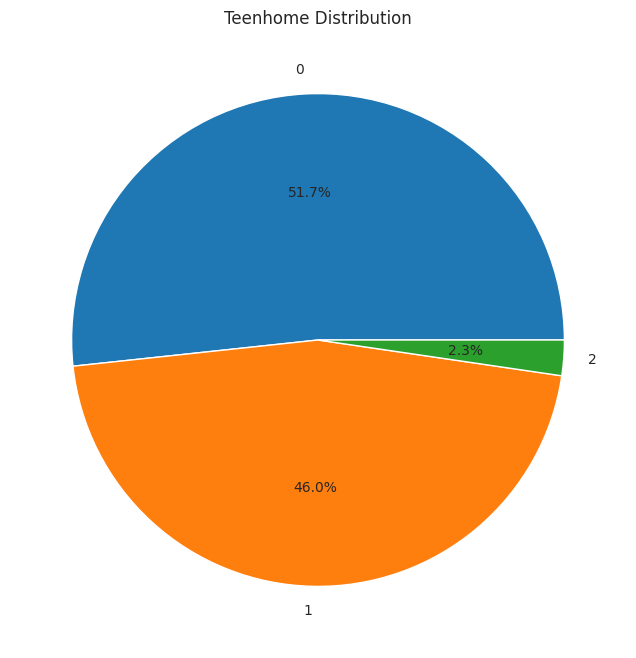

In [33]:
plt.figure(figsize=(8, 8))
plt.pie(customer_data['Teenhome'].value_counts(), labels=customer_data['Teenhome'].value_counts().index, autopct='%1.1f%%')
plt.title('Teenhome Distribution')
plt.show()

In [34]:
customer_data.Recency.value_counts()

Recency
56    37
30    32
54    32
46    31
92    30
      ..
41    15
59    14
22    13
7     12
44    11
Name: count, Length: 100, dtype: int64

In [35]:
customer_data.Complain.value_counts()

Complain
0    2219
1      21
Name: count, dtype: int64

Text(0.5, 1.0, 'Complain Distribution')

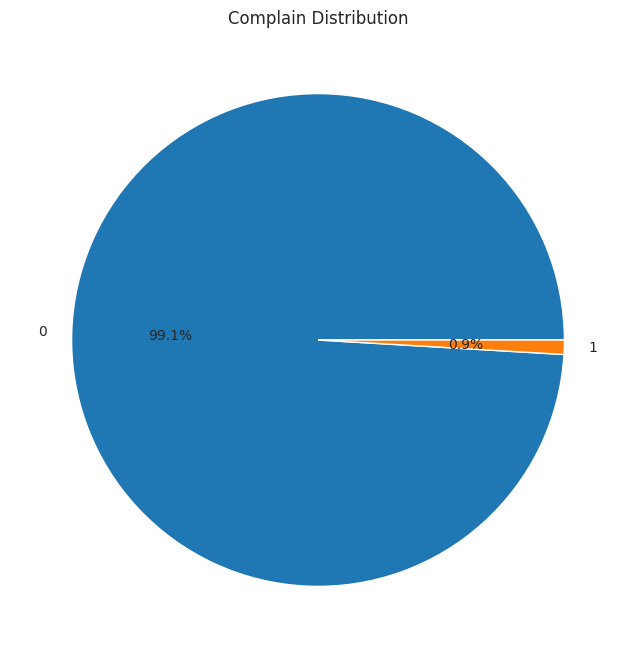

In [36]:
plt.figure(figsize=(8, 8))
plt.pie(customer_data['Complain'].value_counts(), labels=customer_data['Complain'].value_counts().index, autopct='%1.1f%%')
plt.title('Complain Distribution')

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

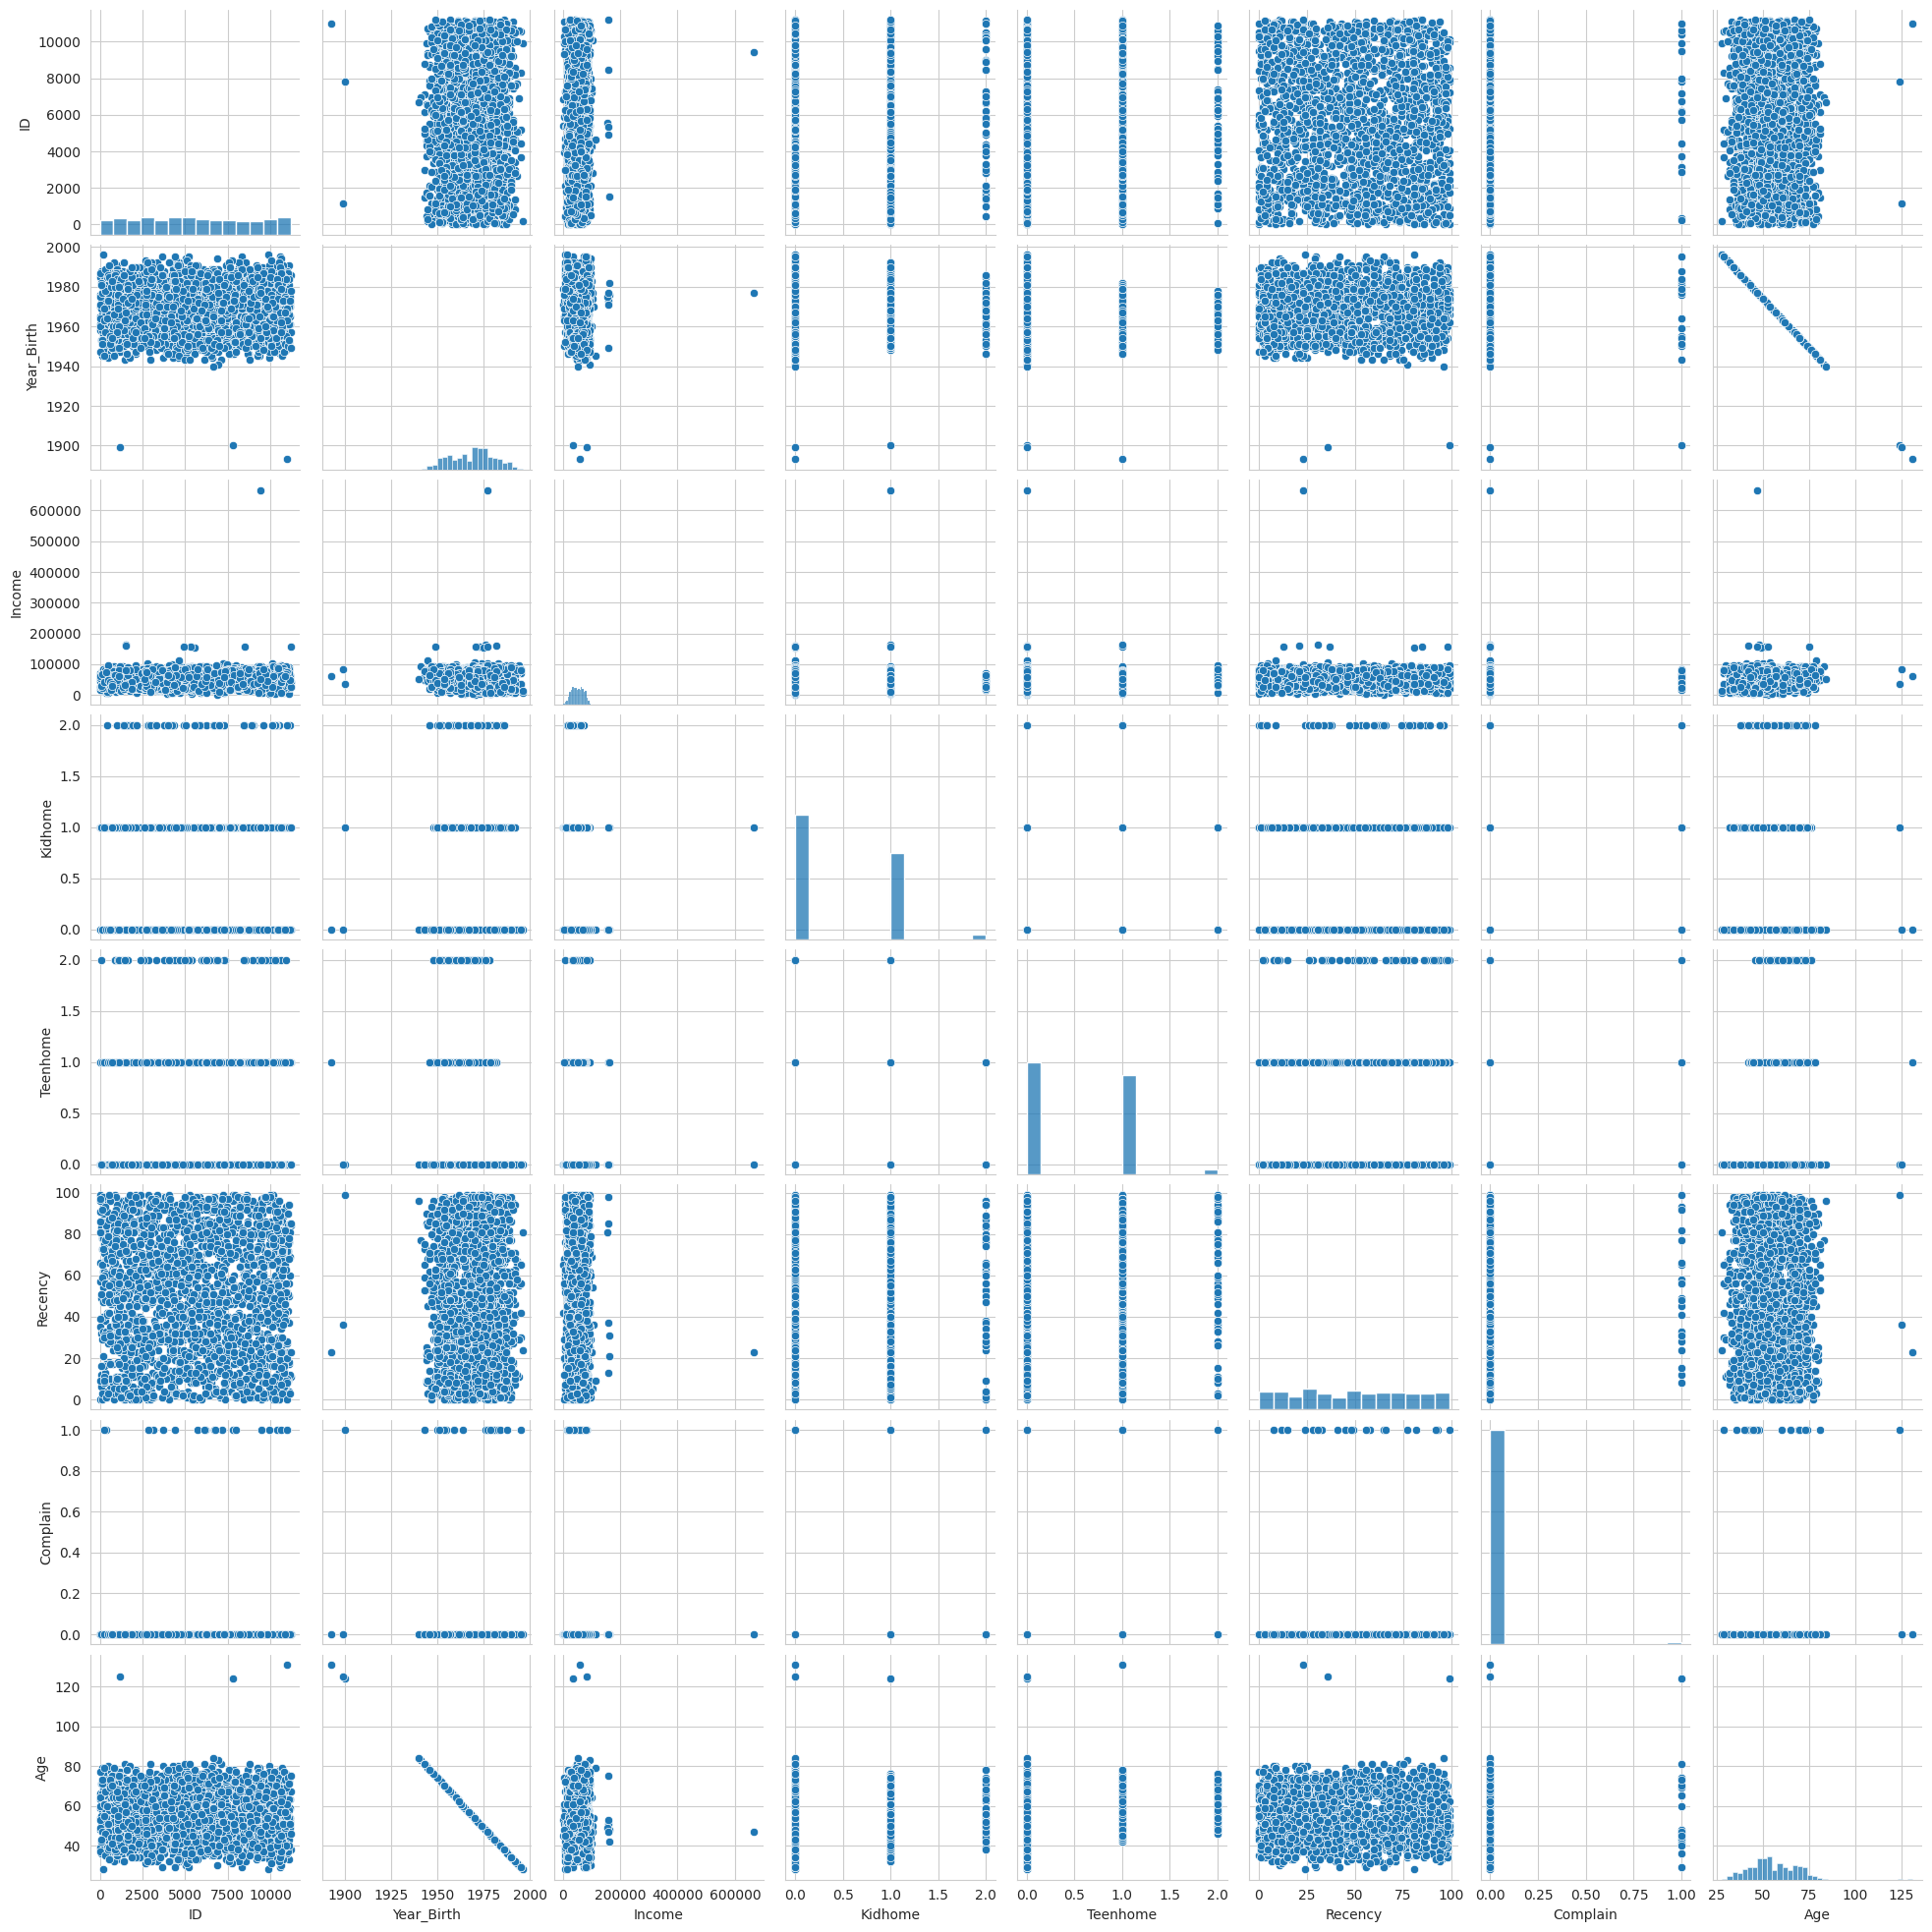

In [37]:
sns.pairplot(data=customer_data)

In [38]:
pd.crosstab(customer_data.Income,customer_data.Age)

Age,28,29,30,31,32,33,34,35,36,37,...,77,78,79,80,81,83,84,124,125,131
Income,,,,,,,,,,,,,,,,,,,,,
1730.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2447.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3502.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4023.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4428.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157243.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
157733.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
160803.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
pd.crosstab(customer_data.Education,customer_data.Income)

Income,1730.0,2447.0,3502.0,4023.0,4428.0,4861.0,5305.0,5648.0,6560.0,6835.0,...,105471.0,113734.0,153924.0,156924.0,157146.0,157243.0,157733.0,160803.0,162397.0,666666.0
Education,,,,,,,,,,,,,,,,,,,,,
2n Cycle,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Basic,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Graduation,1,1,1,0,1,1,1,0,0,0,...,1,0,1,0,1,0,0,0,0,1
Master,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
PhD,0,0,0,1,0,0,0,1,0,1,...,0,1,0,1,0,1,0,1,1,0


In [40]:
pd.crosstab(customer_data.Education,customer_data.Marital_Status)

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,0,0,23,81,37,57,5,0
Basic,0,0,1,20,18,14,1,0
Graduation,1,1,119,433,252,286,35,0
Master,1,1,37,138,75,106,12,0
PhD,0,1,52,192,98,117,24,2


In [41]:
pd.crosstab(customer_data.Education,customer_data.Kidhome)

Kidhome,0,1,2
Education,,,
2n Cycle,109,91,3
Basic,20,34,0
Graduation,650,453,24
Master,211,150,9
PhD,303,171,12


In [42]:
pd.crosstab(customer_data.Education,customer_data.Kidhome)

Kidhome,0,1,2
Education,,,
2n Cycle,109,91,3
Basic,20,34,0
Graduation,650,453,24
Master,211,150,9
PhD,303,171,12


(array([189., 506., 685., 541., 300.,  16.,   0.,   0.,   0.,   3.]),
 array([ 28. ,  38.3,  48.6,  58.9,  69.2,  79.5,  89.8, 100.1, 110.4,
        120.7, 131. ]),
 <BarContainer object of 10 artists>)

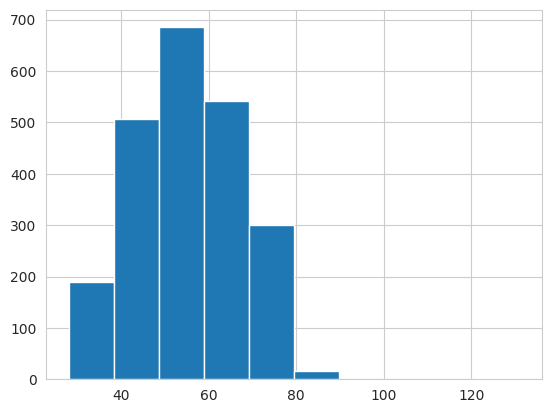

In [43]:
plt.hist(customer_data['Age'])

<Axes: xlabel='Marital_Status', ylabel='count'>

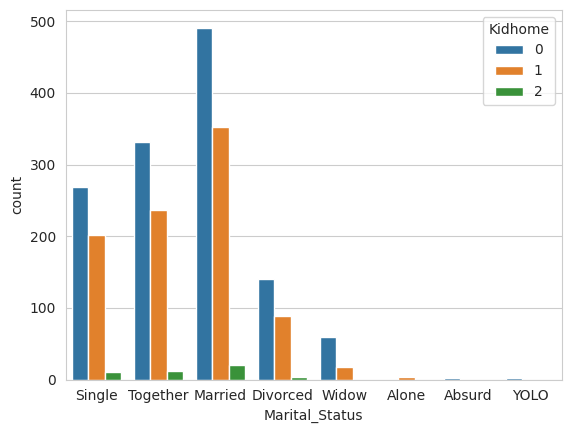

In [44]:
sns.countplot(x="Marital_Status", hue="Kidhome", data=customer_data)

<Axes: xlabel='Marital_Status', ylabel='count'>

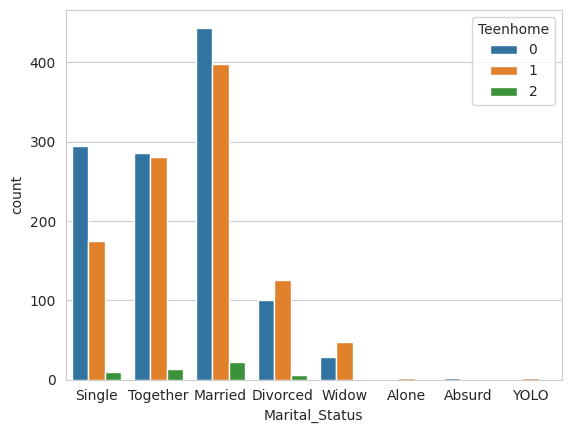

In [45]:
sns.countplot(x="Marital_Status", hue='Teenhome', data=customer_data)

<Axes: xlabel='Marital_Status', ylabel='count'>

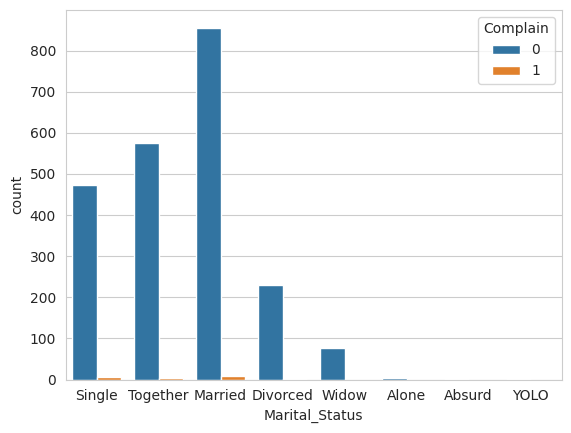

In [46]:
sns.countplot(x="Marital_Status", hue='Complain', data=customer_data)

<Axes: xlabel='Education', ylabel='count'>

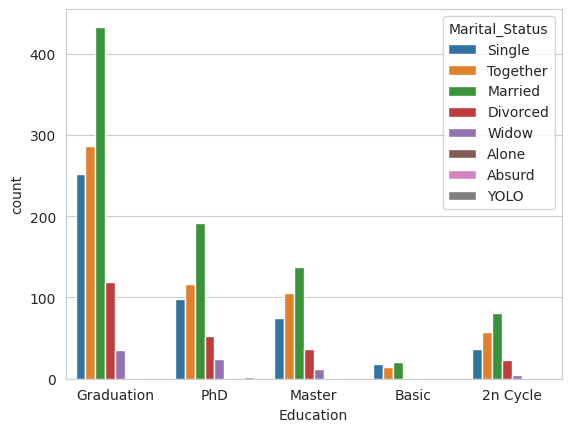

In [47]:
sns.countplot(x="Education", hue='Marital_Status', data=customer_data)

<Axes: xlabel='Education', ylabel='count'>

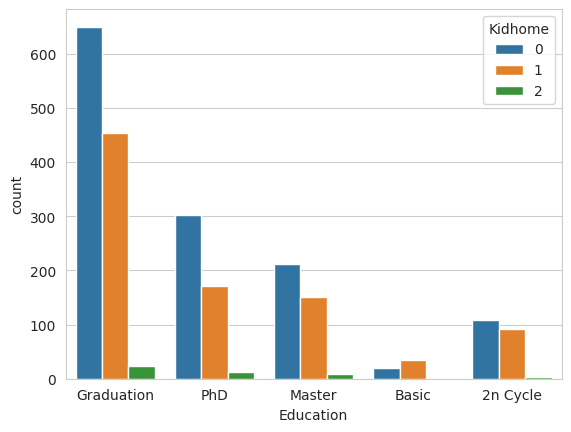

In [48]:
sns.countplot(x="Education", hue='Kidhome', data=customer_data)

<Axes: xlabel='Education', ylabel='count'>

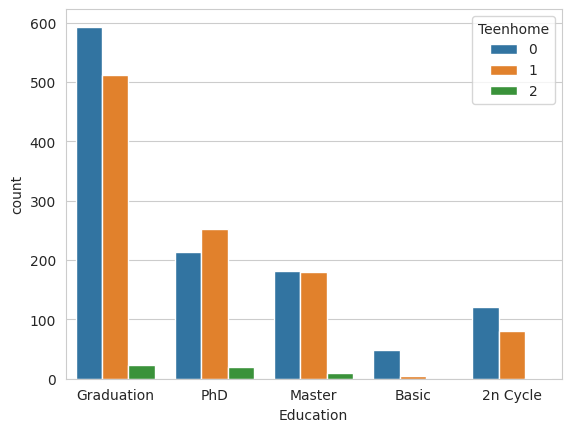

In [49]:
sns.countplot(x="Education", hue='Teenhome', data=customer_data)

<Axes: xlabel='Education', ylabel='count'>

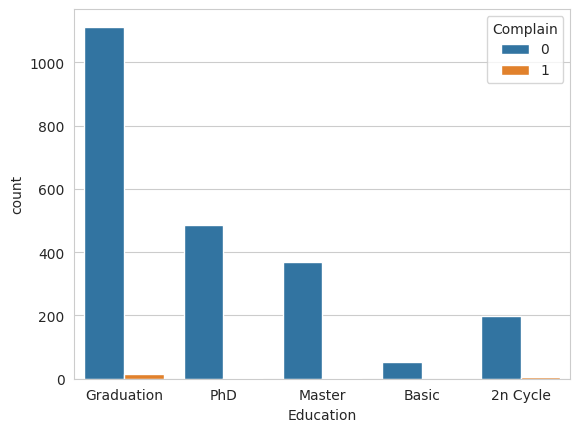

In [50]:
sns.countplot(x="Education", hue='Complain', data=customer_data)

In [51]:
customer_data.columns 

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'Complain', 'Age'],
      dtype='object')

> Products

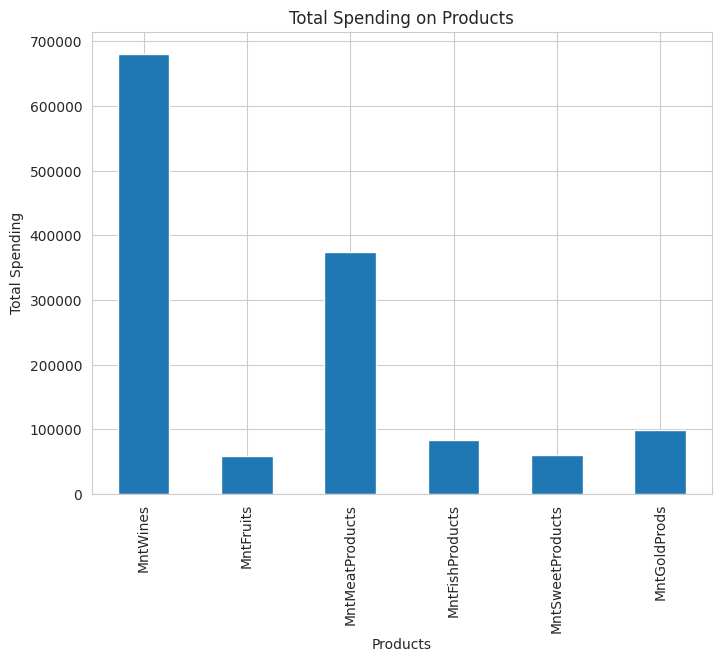

In [52]:
Products = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
total_spent = df[Products].sum()
plt.figure(figsize=(8,6))
total_spent.plot(kind='bar')
plt.title('Total Spending on Products')
plt.xlabel('Products')
plt.ylabel('Total Spending')
plt.show()

In [53]:
df.groupby('Marital_Status')[Products].mean()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Marital_Status,,,,,,
Absurd,355.500000,84.500000,312.500000,205.500000,30.500000,204.000000
Alone,184.666667,4.000000,26.333333,7.666667,7.000000,27.000000
Divorced,324.844828,27.426724,150.206897,35.043103,26.818966,46.288793
Married,299.480324,25.734954,160.681713,35.380787,26.701389,42.822917
Single,288.331250,26.835417,182.108333,38.216667,27.262500,43.729167
Together,306.825862,25.350000,168.103448,38.991379,26.122414,42.994828
Widow,369.272727,33.090909,189.285714,51.389610,39.012987,56.766234
YOLO,322.000000,3.000000,50.000000,4.000000,3.000000,42.000000


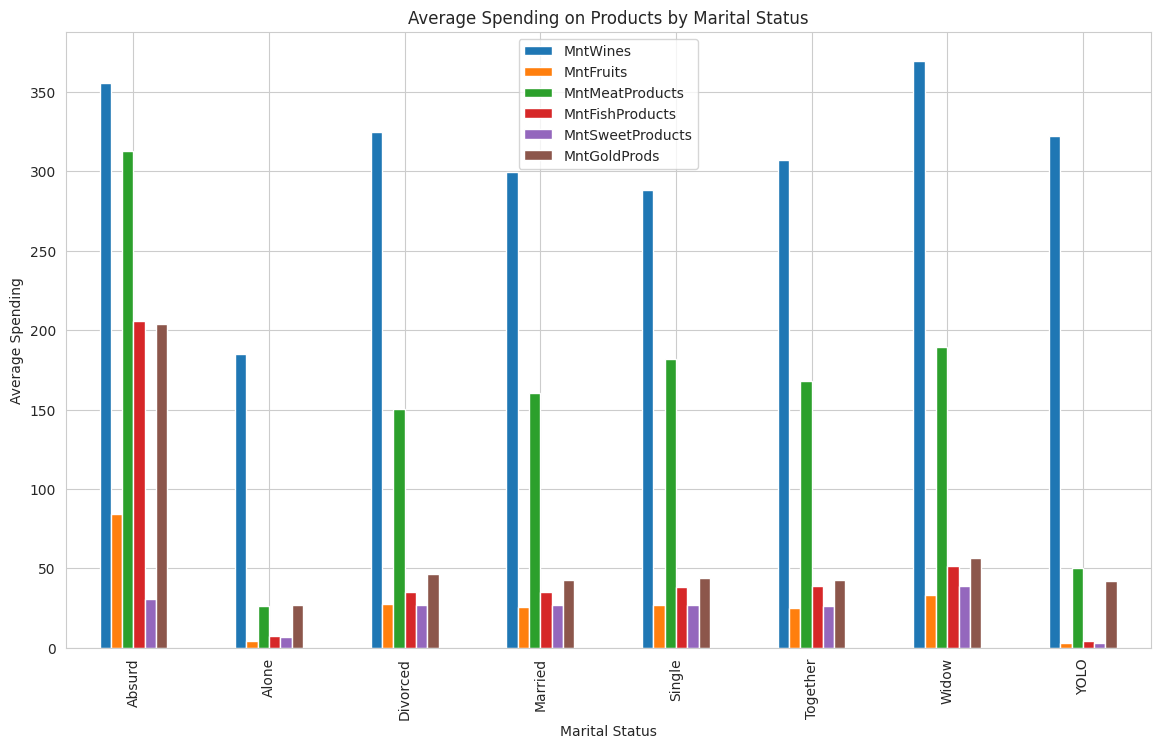

In [54]:
df.groupby('Marital_Status')[Products].mean().plot(kind='bar', figsize=(14,8))
plt.title('Average Spending on Products by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Average Spending')
plt.show()

In [55]:
df.groupby('Kidhome')[Products].mean()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Kidhome,,,,,,
0,451.173241,39.392885,253.996133,56.162413,40.498840,60.037123
1,104.403782,8.517241,48.862069,12.311457,8.932147,22.408231
2,74.791667,6.770833,33.833333,7.729167,4.708333,17.416667


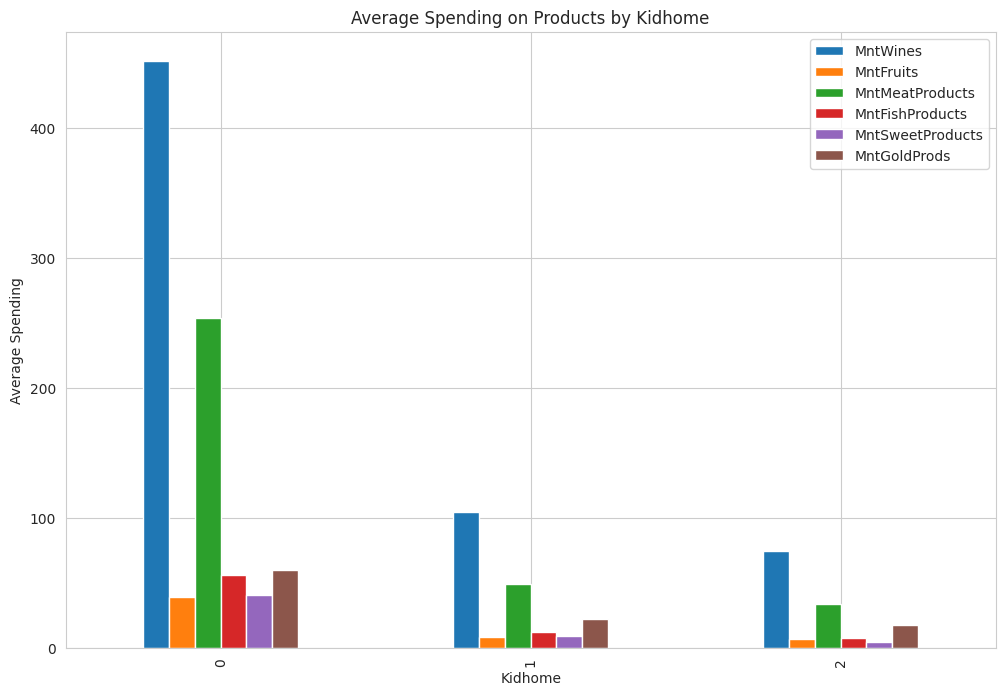

In [56]:
df.groupby('Kidhome')[Products].mean().plot(kind='bar', figsize=(12,8))
plt.title('Average Spending on Products by Kidhome')
plt.xlabel('Kidhome')
plt.ylabel('Average Spending')
plt.show()

In [57]:
df.groupby('Teenhome')[Products].mean()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Teenhome,,,,,,
0,304.822971,33.310017,227.120035,48.658031,33.631261,45.256477
1,300.009709,18.866990,101.432039,25.697087,20.233010,42.587379
2,361.942308,17.519231,124.769231,23.903846,16.076923,44.942308


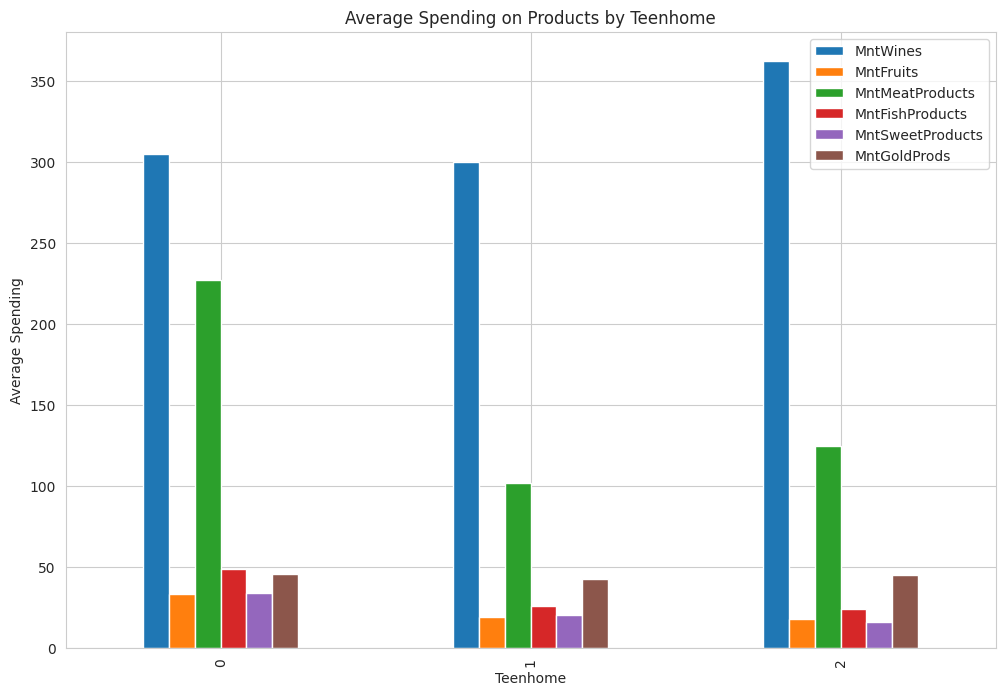

In [58]:
df.groupby('Teenhome')[Products].mean().plot(kind='bar', figsize=(12,8))
plt.title('Average Spending on Products by Teenhome')
plt.xlabel('Teenhome')
plt.ylabel('Average Spending')
plt.show()

In [59]:
df.groupby('Education')[Products].mean()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Education,,,,,,
2n Cycle,198.182266,28.955665,141.256158,47.482759,34.251232,46.399015
Basic,7.240741,11.111111,11.444444,17.055556,12.111111,22.833333
Graduation,284.268855,30.774623,179.488909,43.149956,31.367347,50.849157
Master,333.075676,21.654054,163.378378,32.100000,21.175676,40.397297
PhD,404.495885,20.049383,168.602881,26.728395,20.222222,32.310700


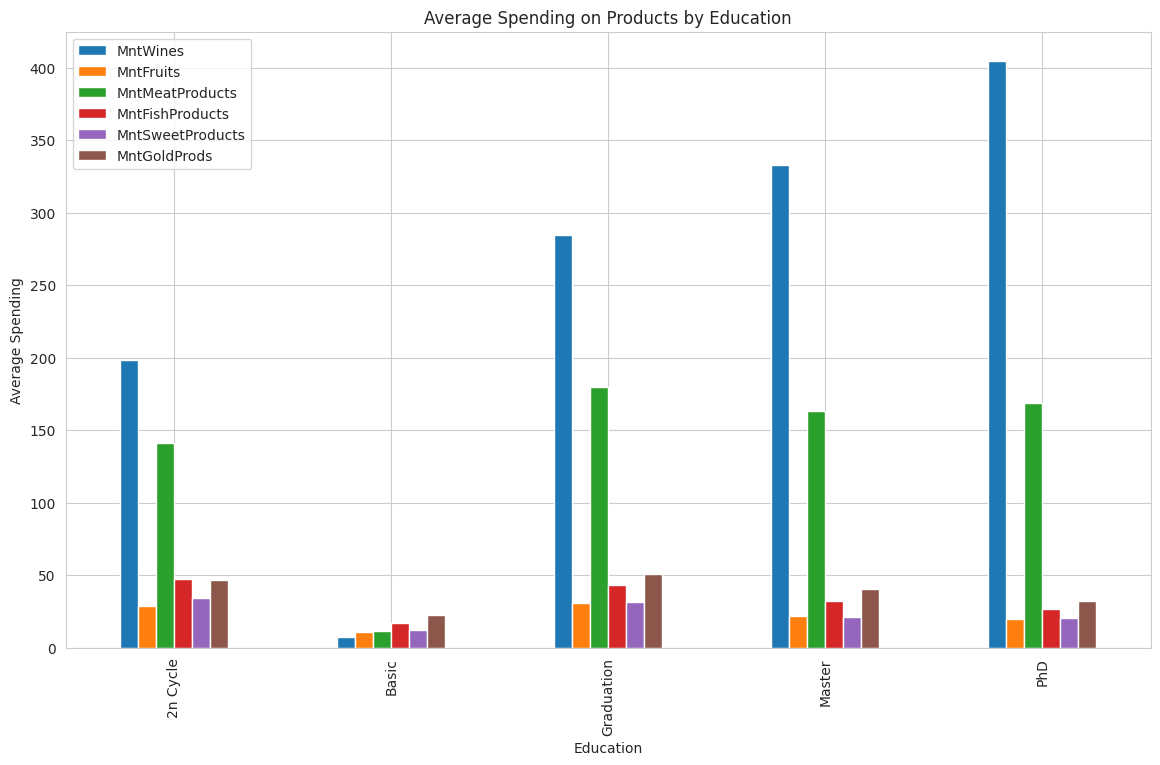

In [60]:
df.groupby('Education')[Products].mean().plot(kind='bar', figsize=(14,8))
plt.title('Average Spending on Products by Education')
plt.xlabel('Education')
plt.ylabel('Average Spending')
plt.show()

> Place

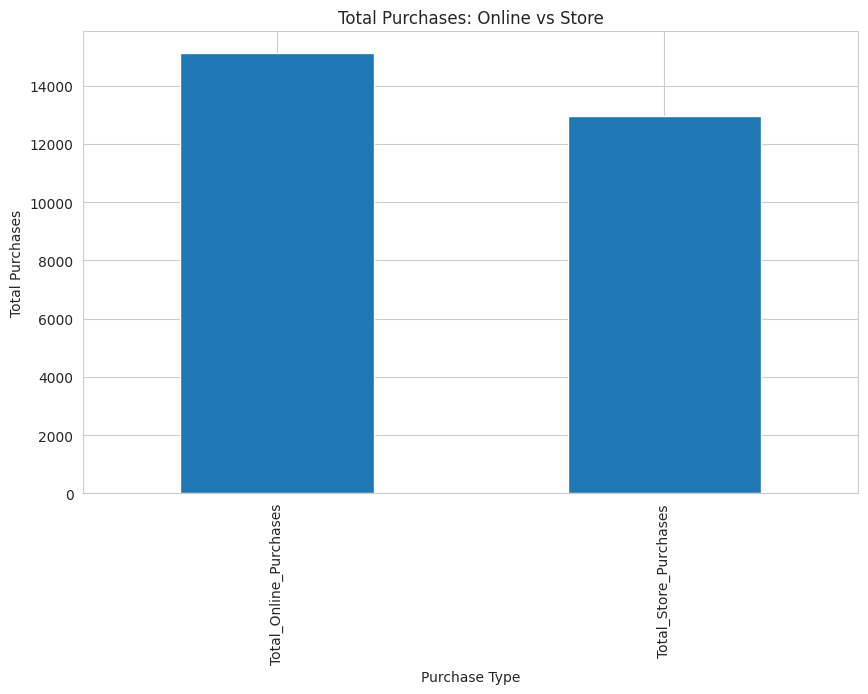

In [61]:
df['Total_Online_Purchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases']
df['Total_Store_Purchases'] = df['NumStorePurchases']

online_vs_store = df[['Total_Online_Purchases', 'Total_Store_Purchases']].sum()
plt.figure(figsize=(10,6))
online_vs_store.plot(kind='bar')
plt.title('Total Purchases: Online vs Store')
plt.xlabel('Purchase Type')
plt.ylabel('Total Purchases')
plt.show()

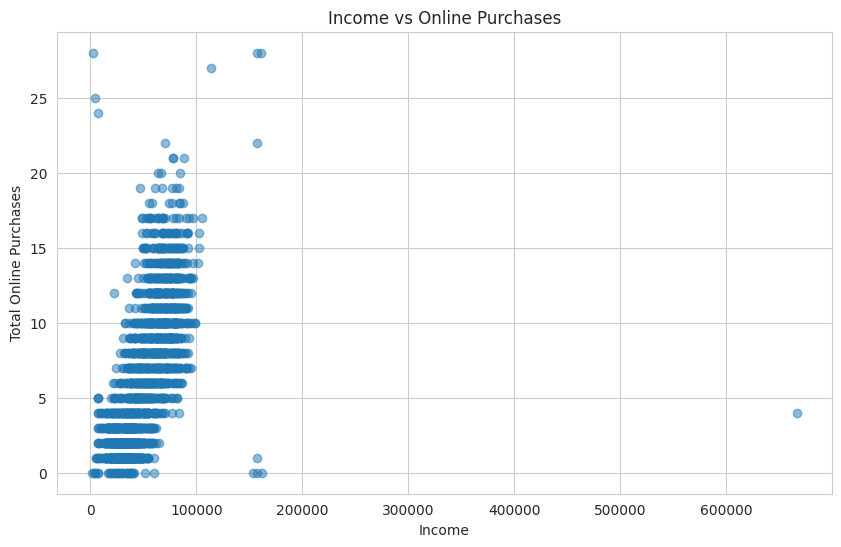

In [62]:
plt.figure(figsize=(10,6))
plt.scatter(df['Income'], df['Total_Online_Purchases'], alpha=0.5)
plt.title('Income vs Online Purchases')
plt.xlabel('Income')
plt.ylabel('Total Online Purchases')
plt.show()

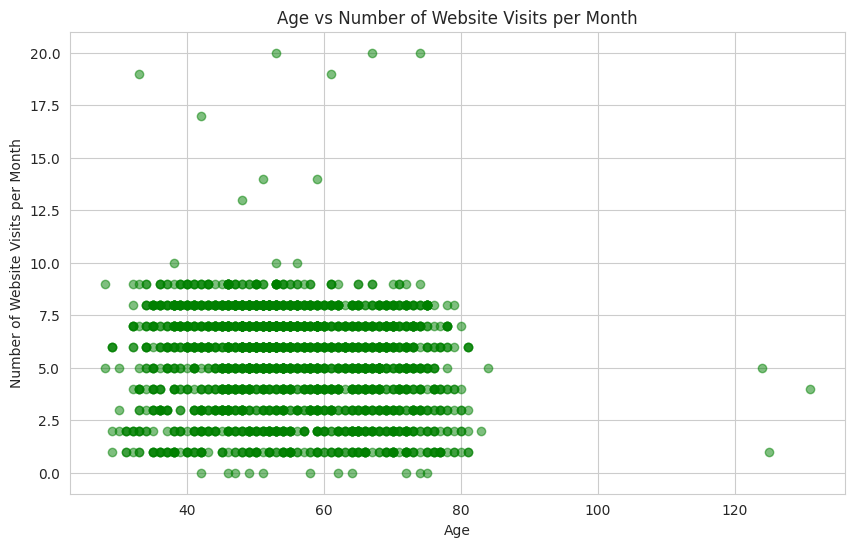

In [63]:
plt.figure(figsize=(10,6))
plt.scatter(customer_data['Age'], df['NumWebVisitsMonth'], alpha=0.5, color='green')
plt.title('Age vs Number of Website Visits per Month')
plt.xlabel('Age')
plt.ylabel('Number of Website Visits per Month')
plt.show()

> promotions

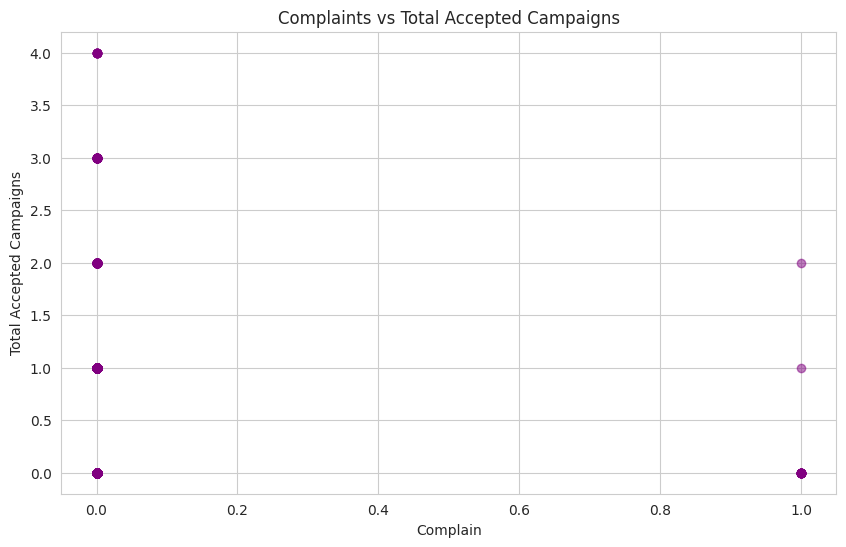

In [64]:
acceptance_columns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
df['Total_Accepted_Cmp'] = df[acceptance_columns].sum(axis=1)

plt.figure(figsize=(10,6))
plt.scatter(df['Complain'], df['Total_Accepted_Cmp'], alpha=0.5, color='purple')
plt.title('Complaints vs Total Accepted Campaigns')
plt.xlabel('Complain')
plt.ylabel('Total Accepted Campaigns')
plt.show()

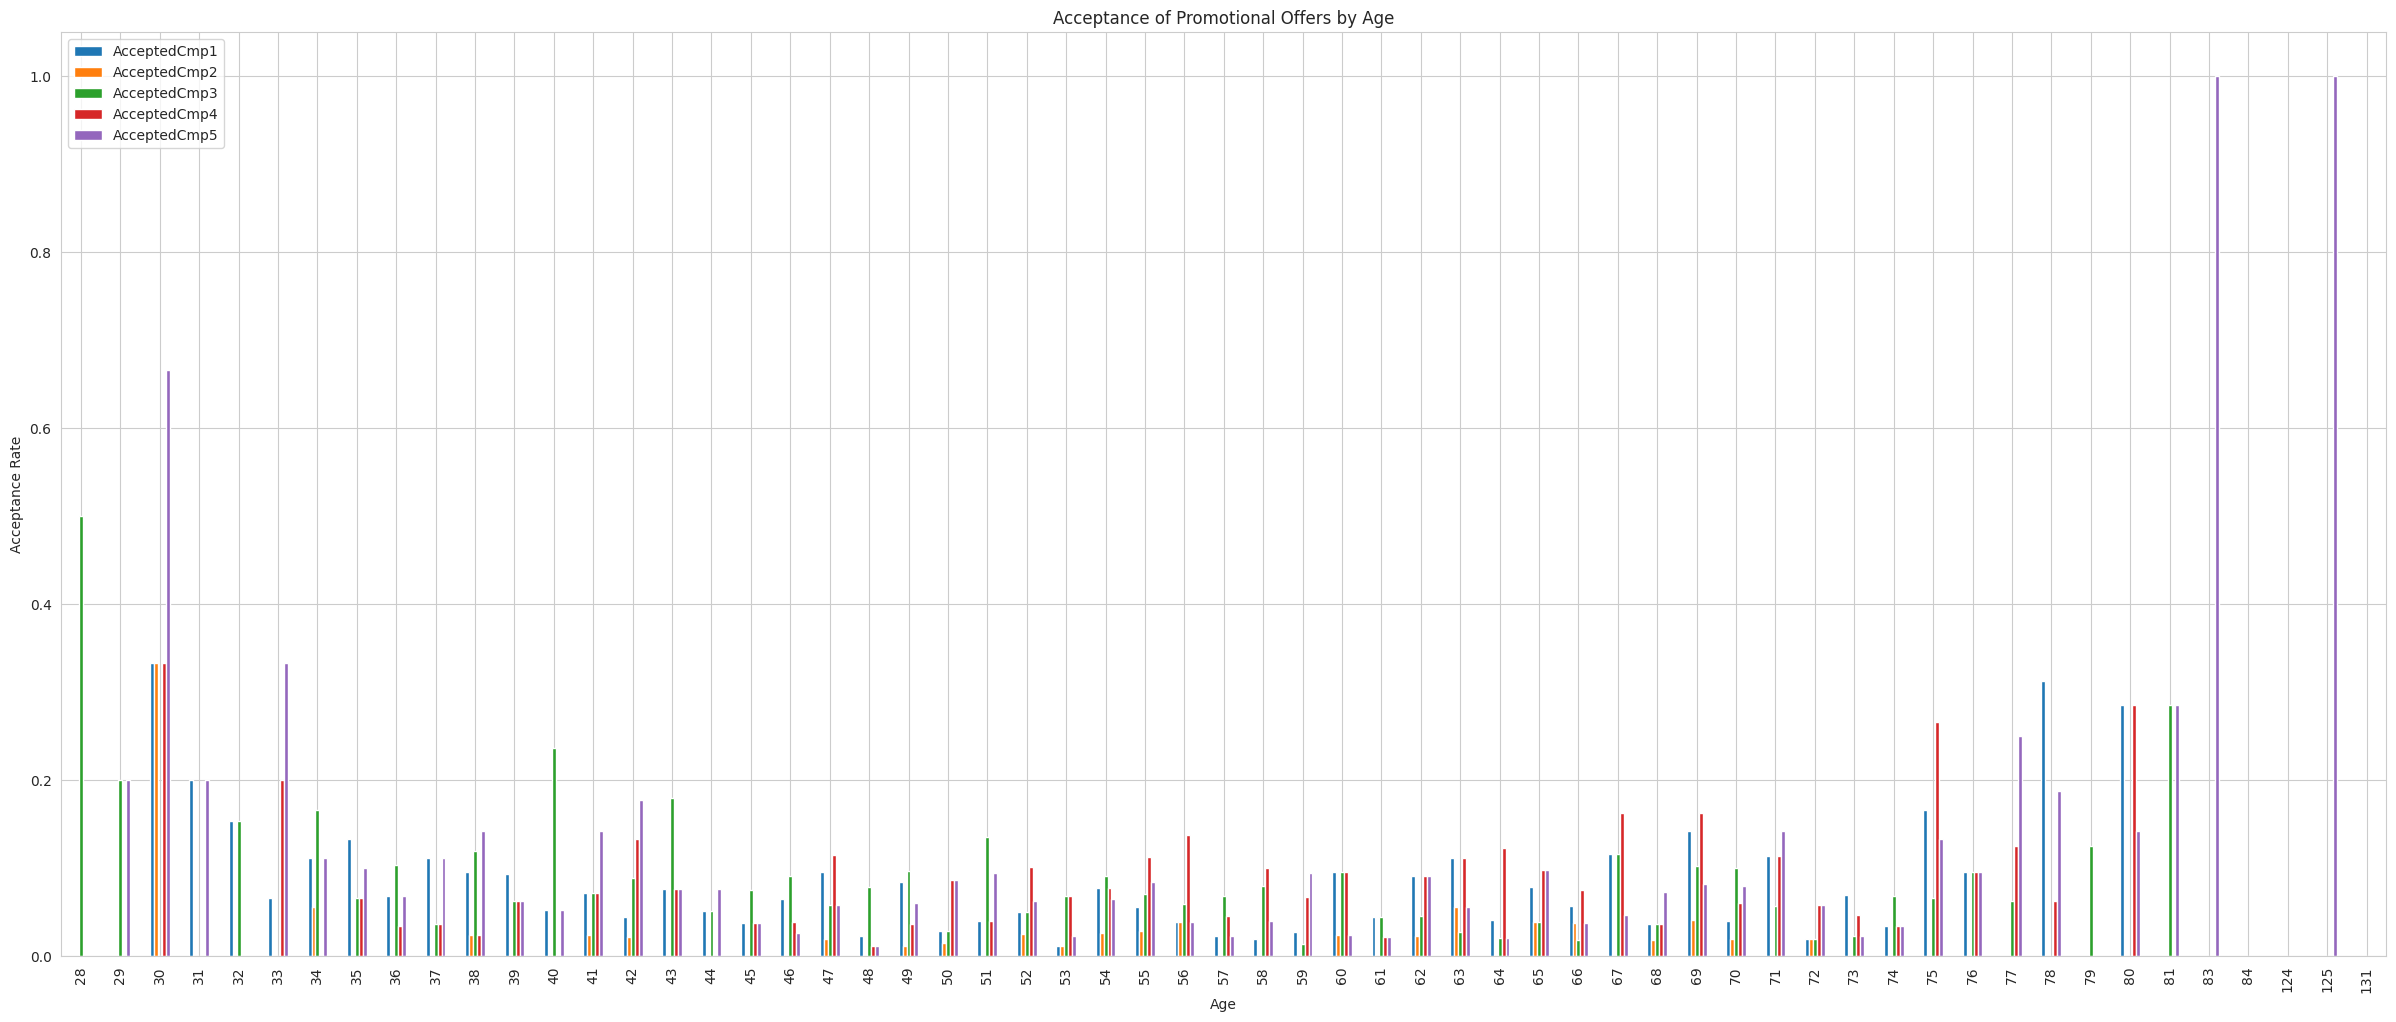

In [65]:
response_by_age_group = df.groupby(customer_data['Age'])[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].mean()
response_by_age_group.plot(kind='bar', figsize=(30,12))
plt.title('Acceptance of Promotional Offers by Age')
plt.xlabel('Age')
plt.ylabel('Acceptance Rate')
plt.show()

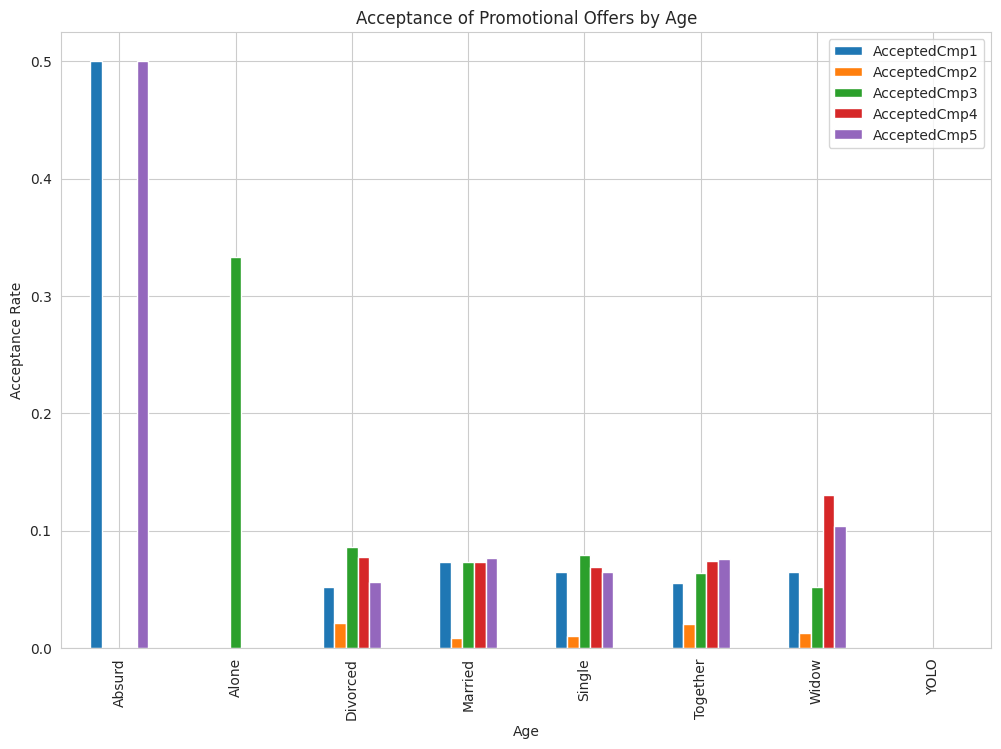

In [66]:
response_by_age_group = df.groupby('Marital_Status')[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].mean()
response_by_age_group.plot(kind='bar', figsize=(12,8))
plt.title('Acceptance of Promotional Offers by Age')
plt.xlabel('Age')
plt.ylabel('Acceptance Rate')
plt.show()

In [67]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Total_Online_Purchases', 'Total_Store_Purchases',
       'Total_Accepted_Cmp'],
      dtype='object')